# Boundary QA

This notebook does a quick quality-assurance pass over the example boundary files.

It checks:
- expected geography keys
- geometry types
- join coverage against the point-capable demo service-request records
- a basemap-backed boundary and point preview

In [1]:
from pathlib import Path
import sys

import nyc311
from IPython.display import display

repo_root = Path(nyc311.__file__).resolve().parents[2]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.utils import data_path, save_boundary_preview

boundaries_gdf = nyc311.load_boundaries_geodataframe(
    data_path("community_district_boundaries.geojson")
)
records = nyc311.load_service_requests(data_path("service_requests_fixture.csv"))
points_gdf = nyc311.records_to_geodataframe(records)
joined = nyc311.spatial_join_records_to_boundaries(
    points_gdf,
    boundaries_gdf,
)

In [2]:
boundary_summary = boundaries_gdf.assign(
    geometry_type=boundaries_gdf.geometry.geom_type,
)[["geography", "geography_value", "geometry_type"]]

join_coverage = joined["boundary_geography_value"].notna().mean()
print(f"Join coverage: {join_coverage:.1%}")
display(boundary_summary)

Join coverage: 94.4%


,geography,geography_value,geometry_type
0,community_district,BROOKLYN 01,Polygon
1,community_district,BROOKLYN 03,Polygon
2,community_district,MANHATTAN 10,Polygon
3,community_district,QUEENS 02,Polygon


PosixPath('/Users/blaise/Desktop/blaise-oss/nyc311/examples/output/community-district-boundary-preview.png')

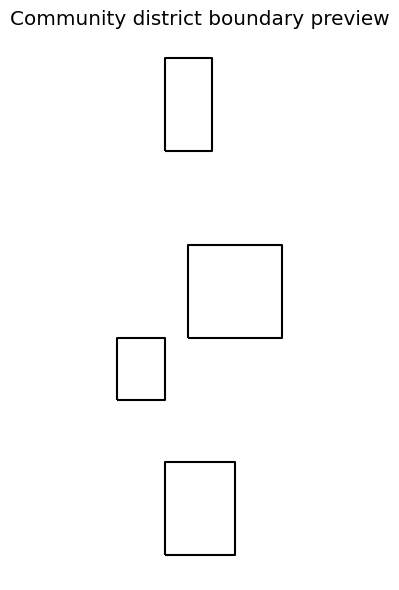

In [3]:
preview_path = save_boundary_preview(
    boundaries_gdf,
    points_gdf=points_gdf,
    filename="community-district-boundary-preview.png",
    title="Community district boundaries and joined points",
)
preview_path